# Food Delivery Time Prediction
# Week 2 Rigorous Modelling

# Objectives
- To rebuild the machine learning pipeline developed in Week 1 using a more rigorous and reproducible methodology. The Week 1 model achieved an R² score of 0.98, which requires further investigation before it can be considered reliable. This notebook focuses on validating that result, rebuilding the modelling pipeline with justified decisions, and evaluating the final model using appropriate validation techniques.

In [3]:
# ==========================================================
# Import Required Libraries
# ==========================================================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configure notebook display
pd.set_option("display.max_columns", None)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


# Loading the Dataset

The dataset is loaded and inspected before any preprocessing or modelling is performed.

In [4]:
# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv("data/food_delivery_analytics_cleaned.csv")

print(f"Dataset Shape : {df.shape}")

df.head()

Dataset Shape : (15000, 30)


,order_id,city_tier,customer_age,customer_loyalty_score,order_hour,order_day_of_week,order_month,delivery_distance_km,preparation_time_minutes,delivery_time_minutes,estimated_delivery_time,traffic_level_score,weather_severity_score,restaurant_rating,delivery_partner_rating,customer_rating,order_value,delivery_fee,discount_amount,tip_amount,final_amount_paid,number_of_items,cancellation_flag,delayed_delivery_flag,refund_flag,promo_code_used,premium_customer_flag,festival_or_weekend_flag,delivery_partner_experience_years,delivery_efficiency_score
0,5a87c6ab-e4a8-44ef-8852-f7a63e3b3943,2,21,4.957522,20,6,6,14.117144,23,76,68,5.4,2.6,4.3,4.1,2.9,100.000000,14.592602,22.969359,19.940541,111.563784,4,False,False,True,False,False,True,9,71.1
1,8eab78a5-a5c5-41d7-9a5f-5779ee5f2d3d,1,63,38.744721,0,2,2,9.177354,16,34,40,1.0,1.6,4.0,4.2,3.4,100.000000,4.391720,4.434405,16.101949,116.059264,7,False,False,False,True,False,False,12,100.0
2,1338cc5b-e5cf-419f-a7c9-4a2577608715,1,68,45.170997,9,2,11,34.753921,41,152,142,8.3,4.1,4.4,4.2,3.7,100.000000,9.006407,14.979691,17.681454,111.708170,12,False,False,False,False,False,False,10,34.4
3,5277f2fb-b1b3-4f58-9975-12f8f1b71421,2,30,10.573003,6,6,5,26.596184,9,93,93,3.2,8.8,4.8,4.6,4.1,145.113442,11.407034,14.813044,11.593912,153.301345,7,False,False,False,False,True,True,1,45.0
4,df159a97-3a78-4b08-a524-ec433c75b670,2,60,58.284620,12,1,9,26.204152,49,141,134,7.5,9.5,4.0,3.9,4.6,100.000000,11.572232,13.716308,13.272883,111.128807,2,True,False,False,False,False,False,6,25.1


# Dataset Overview

Here the data is examined to understand its structure and data quality, such as- available features, data types, missing values, duplicate values and summary stats.

In [5]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   order_id                           15000 non-null  object 
 1   city_tier                          15000 non-null  int64  
 2   customer_age                       15000 non-null  int64  
 3   customer_loyalty_score             15000 non-null  float64
 4   order_hour                         15000 non-null  int64  
 5   order_day_of_week                  15000 non-null  int64  
 6   order_month                        15000 non-null  int64  
 7   delivery_distance_km               15000 non-null  float64
 8   preparation_time_minutes           15000 non-null  int64  
 9   delivery_time_minutes              15000 non-null  int64  
 10  estimated_delivery_time            15000 non-null  int64  
 11  traffic_level_score                15000 non-null  flo

In [6]:
# Summary Statistics

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,15000,15000,5a87c6ab-e4a8-44ef-8852-f7a63e3b3943,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city_tier,15000.0,NaN,NaN,NaN,2.253133,0.827951,1.0,2.0,3.0,3.0,3.0
customer_age,15000.0,NaN,NaN,NaN,46.569667,16.840706,18.0,32.0,46.0,61.0,75.0
customer_loyalty_score,15000.0,NaN,NaN,NaN,50.017658,28.771665,0.007172,25.199828,50.092268,74.840432,99.989375
order_hour,15000.0,NaN,NaN,NaN,11.470933,6.946134,0.0,5.0,11.0,18.0,23.0
order_day_of_week,15000.0,NaN,NaN,NaN,3.141933,1.809864,1.0,1.0,3.0,5.0,6.0
order_month,15000.0,NaN,NaN,NaN,6.474667,3.454469,1.0,3.0,7.0,9.0,12.0
delivery_distance_km,15000.0,NaN,NaN,NaN,20.133756,11.543488,0.103086,10.13319,20.228709,30.047891,39.998739
preparation_time_minutes,15000.0,NaN,NaN,NaN,32.749667,16.162719,5.0,19.0,33.0,47.0,60.0
delivery_time_minutes,15000.0,NaN,NaN,NaN,94.139267,33.597132,10.0,68.0,95.0,120.0,180.0


In [7]:
# Missing Values

missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": (df.isnull().sum() / len(df)) * 100
})

missing_values.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage (%)
customer_rating,150,1.0
tip_amount,150,1.0
delivery_partner_rating,150,1.0
order_value,0,0.0
delivery_partner_experience_years,0,0.0
festival_or_weekend_flag,0,0.0
premium_customer_flag,0,0.0
promo_code_used,0,0.0
refund_flag,0,0.0
delayed_delivery_flag,0,0.0


In [8]:
# Duplicate Records

duplicate_count = df.duplicated().sum()

print(f"Duplicate Records: {duplicate_count}")

Duplicate Records: 0


# Observation

The data set contains 15000 records. Most variables contain all the info, while 3 variables contain 150 missing i.e (1%) values each and there were no duplicate values. This data set can be used for EDA, about the missing values median is taken as a substitute.

# Distribution of the Target Variable


The distribution of the target variable helps determine whether the data is normally distributed, skewed, or contains extreme values. This information is useful when selecting appropriate modelling and evaluation techniques.

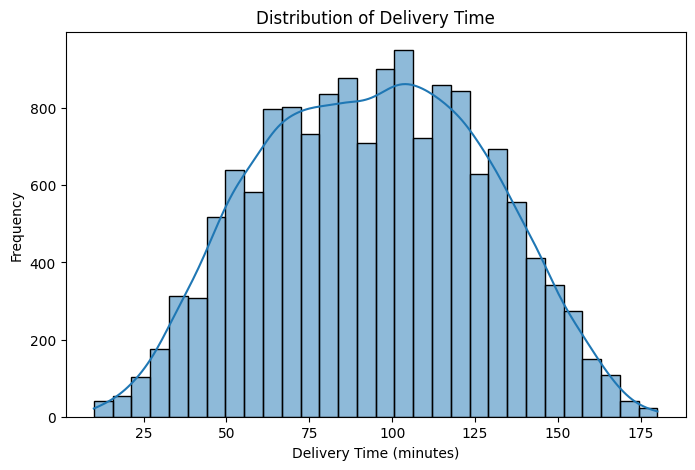

In [37]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["delivery_time_minutes"],
    bins=30,
    kde=True
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Frequency")

plt.show()

# Observation

Delivery times are spread across a wide range, indicating that the model must learn to predict both short and long deliveries.

# Missing values 

Lets find out the missing values in the dataset to avoid data inconsistency.

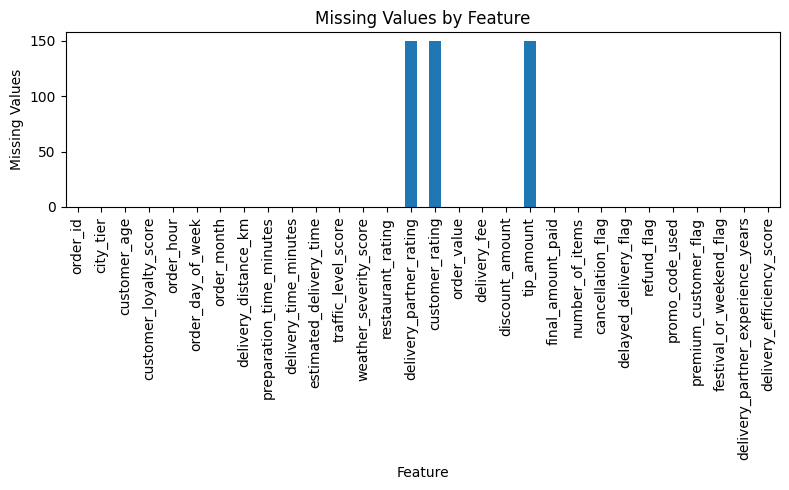

In [39]:
# Missing Values

missing_df = (
    df.isnull()
      .sum()
      .reset_index()
)

missing_df.columns = ["Feature", "Missing Values"]

plt.figure(figsize=(8,5))

missing_df.set_index("Feature")["Missing Values"].plot(
    kind="bar"
)

plt.ylabel("Missing Values")
plt.title("Missing Values by Feature")

plt.tight_layout()

plt.show()

# Observation

customer_rating	150	
tip_amount	150	
delivery_partner_rating	150	
there are 3 missing values to be handled

# Distribution of Important Numerical Features


Examining feature distributions helps identify unusual patterns, and potential preprocessing requirements before model development.

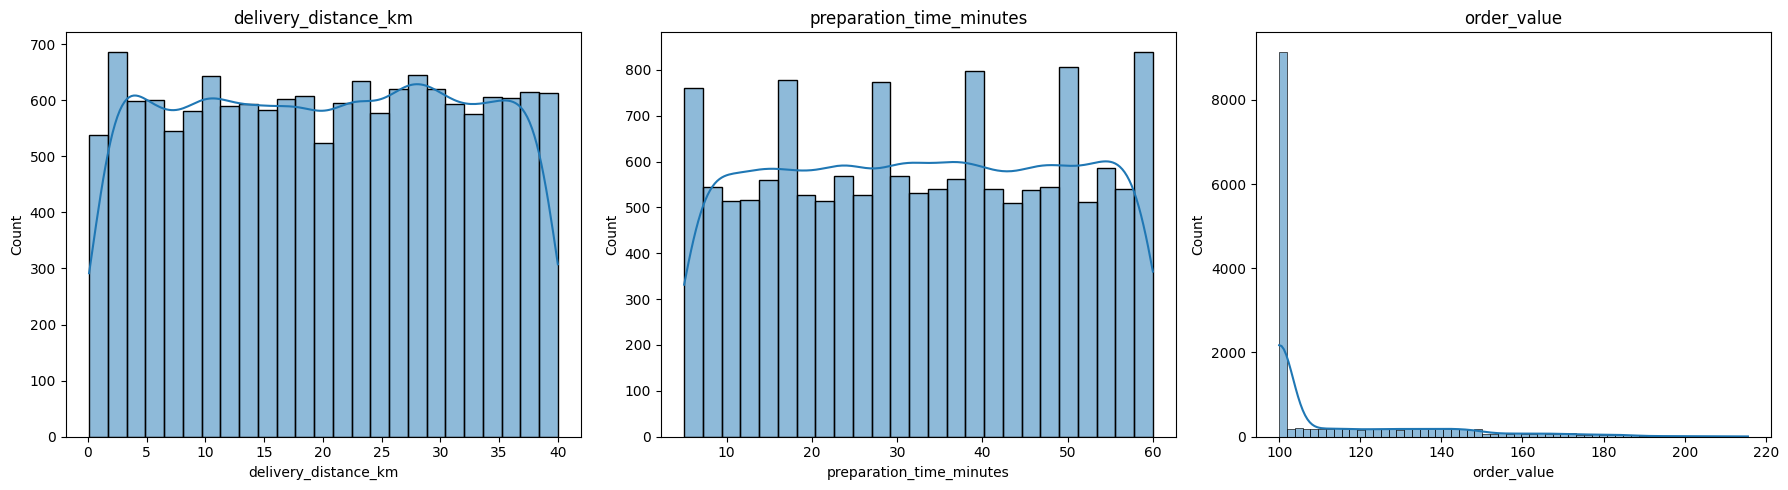

In [ ]:
features = [
    "delivery_distance_km",
    "preparation_time_minutes",
    "order_value"
]

fig, axes = plt.subplots(1,3,figsize=(18,5))

for ax, feature in zip(axes, features):

    sns.histplot(
        df[feature],
        kde=True,
        ax=ax
    )

    ax.set_title(feature)

plt.tight_layout()

plt.show()

# Observation

`delivery_distance_km`,
`preparation_time_minutes`,
`order_value`

These 3 values contribute in predicting the target value(delivery time).

#  Correlation Analysis

This analysis helps identify highly correlated features, understand potential predictors of the target variable, and detect variables that require further investigation during feature selection.

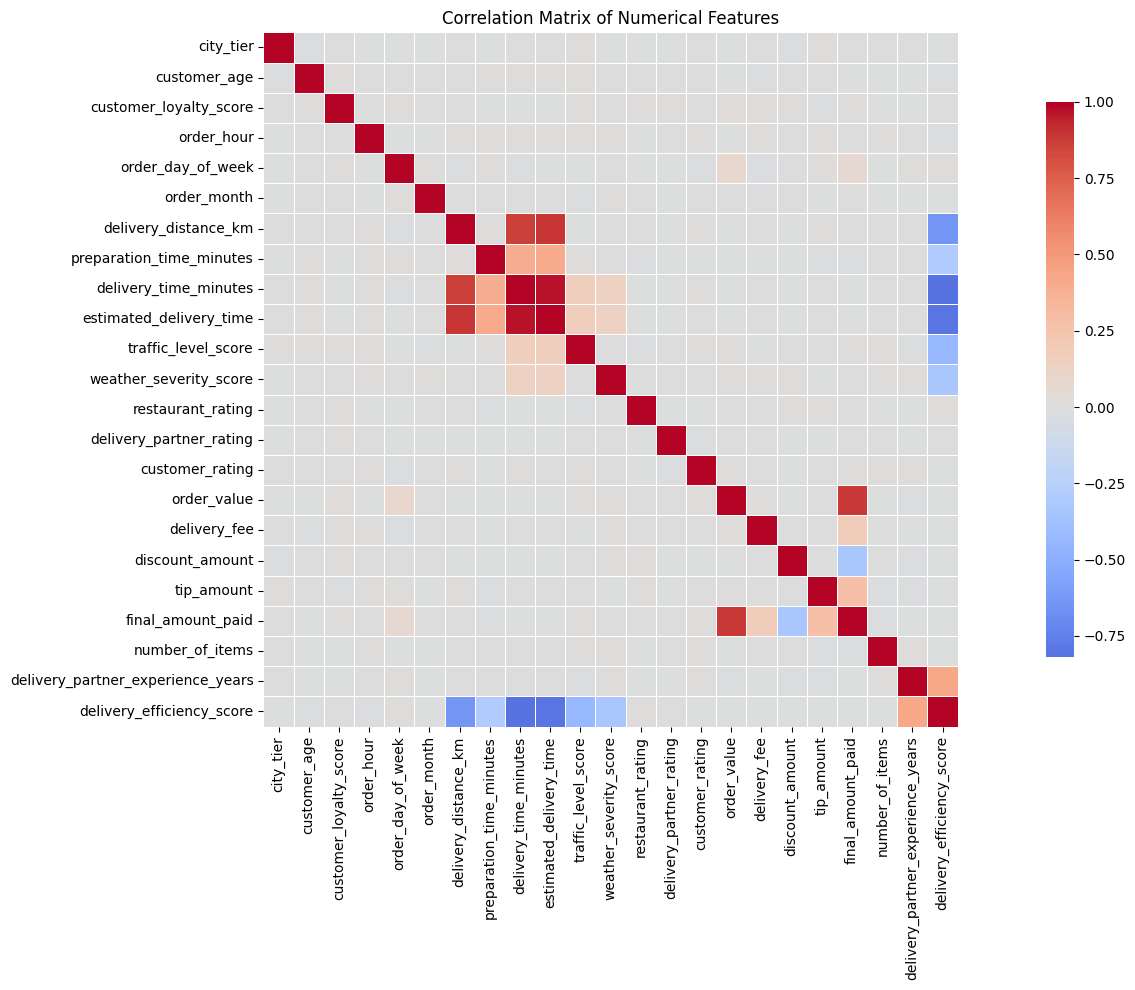

In [ ]:
plt.figure(figsize=(18,10))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink":0.8}
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()

plt.show()

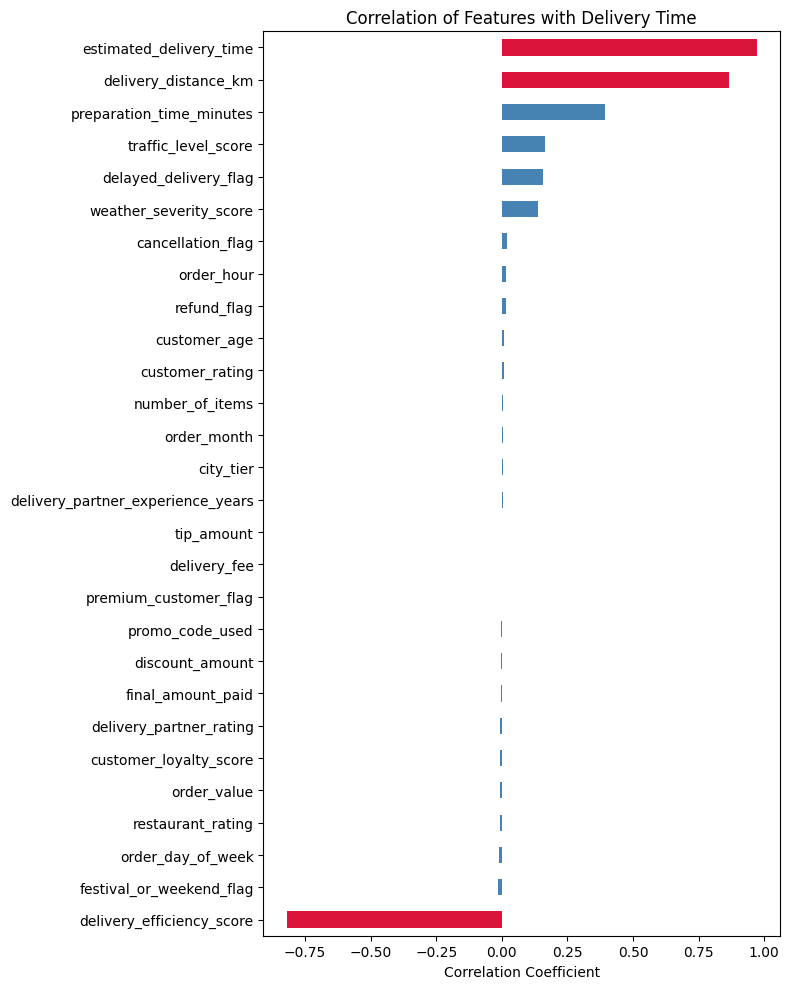

In [ ]:
# Correlation with Target Variable

target_corr = (
    df.corr(numeric_only=True)["delivery_time_minutes"]
    .drop("delivery_time_minutes")
    .sort_values()
)

plt.figure(figsize=(8,10))

colors = [
    "crimson" if abs(value) >= 0.7 else "steelblue"
    for value in target_corr
]

target_corr.plot(
    kind="barh",
    color=colors
)

plt.xlabel("Correlation Coefficient")
plt.title("Correlation of Features with Delivery Time")

plt.tight_layout()

plt.show()

# Observation

The analysis indicate that the `estimated_delivery_time` has the strongest positive relationship with the target variable, followed by `delivery_distance_km` and `preparation_time_minutes`. These relationships are expected, as delivery time is directly influenced by travel distance and food preparation time.

The `delivery_efficiency_score` exhibits a strong negative correlation with the target variable. Although this raises concerns about potential target leakage, correlation alone is not sufficient evidence to conclude that the feature is derived from the target. So this requires further investigation too.

Most of the remaining variables show only weak correlations with the target, thus they contribute less individually to predicting delivery time.

## Investigating the Week 1 Rg modell

From here on the investigation of the Week 1

# Problem Statement

The model developed during Week 1 achieved an R^2 score of approx to 0.98. Although this indicates excellent predictive performance, such a high score is uncommon for a real-world delivery time prediction problem.

Before proceeding with further model development, it is important to determine whether this performance is genuine or influenced by methodological issues.

Three possible explanations are considered:

1. Data leakage – One or more features may directly or indirectly contain information about the target variable.
2. Overfitting – The model may have memorised the training data rather than learning general patterns.
3. Dataset characteristics – The dataset may genuinely be highly predictable because the available features explain most of the variation in delivery time.

The following experiments are performed to evaluate these possibilities.

In [12]:
# Target variable

target = "delivery_time_minutes"

print("Target Variable :", target)

Target Variable : delivery_time_minutes


In [11]:
# Potential leakage candidates

potential_leakage_features = [
    "estimated_delivery_time",
    "delivery_efficiency_score",
    "delayed_delivery_flag",
    "refund_flag",
    "cancellation_flag"
]

pd.DataFrame(
    {
        "Potential Leakage Features": potential_leakage_features
    }
)

,Potential Leakage Features
0,estimated_delivery_time
1,delivery_efficiency_score
2,delayed_delivery_flag
3,refund_flag
4,cancellation_flag


# Observation

5 features were identified as potential leakage causing variables based on their names and their possible relationship with the target variable.


# Evidence 1: Correlation Analysis

# Objective

In this we  examine how strongly each numerical feature is related to the target variable. Features exhibiting unusually high correlations are treated as candidates for further investigation because they may contain information that would not normally be available when making predictions.

In [13]:
# Correlation with the target variable

target_corr = (
    df.corr(numeric_only=True)["delivery_time_minutes"]
    .sort_values(ascending=False)
)

target_corr.to_frame()

,delivery_time_minutes
delivery_time_minutes,1.000000
estimated_delivery_time,0.970722
delivery_distance_km,0.863925
preparation_time_minutes,0.394064
traffic_level_score,0.163487
delayed_delivery_flag,0.157359
weather_severity_score,0.136230
cancellation_flag,0.019753
order_hour,0.015096
refund_flag,0.014846


### Observation

The analysis shows that `estimated_delivery_time` has an exceptionally strong positive correlation with the target variable (r=0.97). Similarly, `delivery_efficiency_score` has a strong negative correlation (r=-0.82).

Although high correlation alone does not prove data leakage, these results justify further investigation into whether these features contain information derived from the delivery outcome.

# Evidence 2: Investigating the Delivery Efficiency Score

# Objective

The strong negative correlation between `delivery_efficiency_score` and the target variable raises the possibility that the feature may be mathematically derived from the delivery time. To verify this, the feature was compared with a manually calculated efficiency score. Formula (df["estimated_delivery_time"] / df["delivery_time_minutes"]) * 100

In [14]:
# ==========================================================
# Recalculate Delivery Efficiency Score
# ==========================================================

# Approximate efficiency calculation
calc_efficiency = (
    df["estimated_delivery_time"] /
    df["delivery_time_minutes"]
) * 100

comparison = pd.DataFrame({
    "Actual Efficiency": df["delivery_efficiency_score"],
    "Calculated Efficiency": calc_efficiency.round(1)
})

comparison.head(20)

,Actual Efficiency,Calculated Efficiency
0,71.1,89.5
1,100.0,117.6
2,34.4,93.4
3,45.0,100.0
4,25.1,95.0
5,73.6,109.7
6,58.9,117.2
7,96.6,132.5
8,39.3,75.9
9,51.4,104.0


In [15]:
# ==========================================================
# Difference Between Actual and Calculated Efficiency
# ==========================================================

difference = (
    df["delivery_efficiency_score"] -
    calc_efficiency
).abs()

print("Summary of Differences")
print(difference.describe())

print("\nMaximum Absolute Difference:", difference.max())

Summary of Differences
count    15000.000000
mean        42.569779
std         18.742589
min          0.000000
25%         29.868868
50%         43.106394
75%         55.339415
max        246.500000
dtype: float64

Maximum Absolute Difference: 246.5


### Observation

The manually calculated efficiency values differ substantially from the `delivery_efficiency_score` provided in the dataset. The large differences indicate that the feature is not a simple mathematical transformation of `delivery_time_minutes` and `estimated_delivery_time`.

However, the dataset documentation does not explain how `delivery_efficiency_score` was generated. Since its calculation is unknown and it exhibits a strong correlation with the target variable, it is excluded from the final modelling pipeline as a precaution against potential target leakage.

# Evidence 3: Overfitting Investigation

# Objective

One possible explanation for the unusually high R^2 score is overfitting. To investigate this, the model performance is evaluated on both the training and testing datasets. A large difference between the two would indicate that the model has memorized the training data rather than learned generalizable patterns.

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    root_mean_squared_error
)
from xgboost import XGBRegressor


def evaluate_xgboost(X, y):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )

    model = XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    results = {
        "Train RMSE": root_mean_squared_error(y_train, train_pred),
        "Test RMSE": root_mean_squared_error(y_test, test_pred),
        "Train R²": r2_score(y_train, train_pred),
        "Test R²": r2_score(y_test, test_pred),
        "MAE": mean_absolute_error(y_test, test_pred)
    }

    return results

In [32]:
X_baseline = df.drop(
    columns=[
        "order_id",
        "delivery_time_minutes"
    ]
)

y = df["delivery_time_minutes"]

baseline_results = evaluate_xgboost(X_baseline, y)

baseline_results

{'Train RMSE': 3.5479323863983154,
 'Test RMSE': 4.768283843994141,
 'Train R²': 0.9888269901275635,
 'Test R²': 0.9799839854240417,
 'MAE': 3.8208444118499756}

### Observation

The baseline model achieved a training R^2 score of 0.9888 and a testing R^2 score of 0.9800. Although the training performance is slightly higher, the difference between the two scores is small, indicating that the model generalizes well to unseen data. Therefore, there is no strong evidence that the high performance observed during Week 1 is primarily the result of overfitting.

# Evidence 4: Evaluating Dataset Simplicity

# Objective

A simple Linear Regression model is trained using only the two most main features: `delivery_distance_km` and `preparation_time_minutes`. If this simple model achieves a high R² score, it suggests that the dataset itself is highly predictable and that complex models may not be necessary to achieve strong performance.

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    root_mean_squared_error
)

# Use only the two operational features
X_simple = df[
    [
        "delivery_distance_km",
        "preparation_time_minutes"
    ]
]

y = df["delivery_time_minutes"]

X_train, X_test, y_train, y_test = train_test_split(
    X_simple,
    y,
    test_size=0.20,
    random_state=42
)

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

predictions = linear_model.predict(X_test)

print(f"RMSE : {root_mean_squared_error(y_test, predictions):.2f}")
print(f"MAE  : {mean_absolute_error(y_test, predictions):.2f}")
print(f"R²   : {r2_score(y_test, predictions):.4f}")

RMSE : 10.78
MAE  : 8.71
R²   : 0.8977


# Observation

The model trained using only `delivery_distance_km` and `preparation_time_minutes` achieved an R^2=0.8977. Although this performance is lower than the XGBoost model, it is still high for such a simple model. This indicates that the dataset is inherently predictable, with delivery distance and preparation time explaining a large proportion of the variation in delivery time. Therefore, the high performance observed during Week 1 cannot be attributed solely to data leakage or overfitting.

# Evidence 5: Model Performance After Removing Potential Leakage Features

# Objective

The identified leakage variables are removed from the dataset and the model is retrained. The resulting performance is compared with the baseline to determine whether the model remains effective after excluding these features.

In [34]:
# Features removed from the modelling dataset
features_to_remove = [
    "estimated_delivery_time",
    "delivery_efficiency_score",
    "delayed_delivery_flag",
    "refund_flag",
    "cancellation_flag"
]

X_clean = df.drop(
    columns=[
        "order_id",
        "delivery_time_minutes"
    ] + features_to_remove
)

clean_results = evaluate_xgboost(X_clean, y)

clean_results

{'Train RMSE': 6.439416408538818,
 'Test RMSE': 8.409616470336914,
 'Train R²': 0.9631946086883545,
 'Test R²': 0.9377404451370239,
 'MAE': 6.719733715057373}

# Observation

After removing the identified leakage candidates, the model's test R^2 score decreased from 0.9800 to 0.9377, while the test RMSE increased from 4.77 to 8.41 mins. This indicates that the removed features contributed to the original model performance. However, the improved model continues to achieve strong predictive accuracy, suggesting that the remaining operational features contain info for predicting delivery time. Therefore, excluding these features provides a more reliable model with a lower risk of target leakage.

# Evidence 6: Cross-Validation

# Objective

The final experiment evaluates the stability of the improved model using 5 fold cross validation.

In [35]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# Five-fold Cross Validation
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6
)

scores = cross_val_score(
    cv_model,
    X_clean,
    y,
    cv=kf,
    scoring="r2"
)

print("R² Scores :", scores)
print("Mean R²   :", scores.mean())
print("Std Dev   :", scores.std())

R² Scores : [0.93810141 0.93901145 0.93617105 0.93551344 0.94013155]
Mean R²   : 0.9377857804298401
Std Dev   : 0.0017248417759509185


# Observation

The 5 fold cross validation results are highly consistent across all folds, with R^2 scores ranges from 0.9355 - 0.9401. The model achieved a mean R^2=0.9378 with a SD=0.0017. The low SD indicates that the model performs consistently across different subsets of the data and provides no evidence of significant overfitting. These results suggest that the cleaned model generalizes well to unseen data.

# Conclusion

The unusually high R^2 score obtained during Week 1 was investigated using multiple experiments. Correlation analysis identified `estimated_delivery_time` and `delivery_efficiency_score` as potential leakage variables because of their strong relationship with the target variable. But on further an investigation showed that `delivery_efficiency_score` is not a simple mathematical formula of the target, although its calculation remains undocumented.

To evaluate overfitting, the baseline XGBoost model was assessed on both the training and testing datasets. The training R^2 score (0.9888) and testing R^2 score (0.9800) were very similar, indicating no strong evidence of overfitting. A simple Linear Regression model trained using only `delivery_distance_km` and `preparation_time_minutes` achieved an R^2 score of 0.8977, demonstrating that the dataset is predictable using only a small number of operational features.

Finally, after removing the identified leakage Variables, the model achieved a test R^2 score of 0.9377. 5 fold cross validation produced a mean R^2 score of 0.9378 with a SD of 0.0017, confirming that the improved model generalizes consistently across different data splits. Based on these findings, the remaining experiments in this notebook use the improved dataset to reduce the risk of potential target leakage while maintaining strong predictive performance.